# TensorFlow / Keras / TFLite

Ce notebook résume le workflow complet vu en formation :

1. **Keras** : construire, entraîner et évaluer un réseau de neurones (Dense puis CNN)
2. **TFLite / LiteRT** : convertir, optimiser et quantizer le modèle pour l'embarqué

## Installation

In [1]:
%pip install -q numpy matplotlib scikit-learn tensorflow ai-edge-litert


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)

# keras.utils.set_random_seed(42) # reproductibilité (numpy + tensorflow + python)

TensorFlow : 2.21.0
Keras      : 3.14.1


## Le toy dataset

<div class="alert alert-block alert-info">
	<b>ℹ️ Toy dataset :</b> pour rester autonome (aucun téléchargement) et rapide sur CPU, on génère ici des <b>signaux 1D synthétiques</b> (sinus, carré, dents de scie, bruit).
	<p>C'est un problème où la convolution est pertinente pour la même raison que sur notre IMU : la classe se reconnaît à des <b>motifs locaux</b> dans le temps, peu importe leur position dans la fenêtre.</p>
</div>

Quatre classes de signaux, avec une fréquence, une phase et une amplitude **aléatoires**, plus un bruit de mesure.

Un modèle ne peut donc pas tricher en apprenant par cœur des valeurs : il doit reconnaître la **forme** du signal.

In [3]:
LENGTH = 200
SAMPLES_PER_CLASS = 250
CLASSES = ["sine", "square", "sawtooth", "noise"]

def make_waveform(kind, length=LENGTH, rng=None):
	rng = rng or np.random.default_rng()
	t = np.linspace(0, 1, length)
	freq = rng.uniform(2, 6)
	phase = rng.uniform(0, 2 * np.pi)
	amplitude = rng.uniform(0.5, 1.0)
	arg = 2 * np.pi * freq * t + phase

	if kind == "sine":
		signal = np.sin(arg)
	elif kind == "square":
		signal = np.sign(np.sin(arg))
	elif kind == "sawtooth":
		signal = 2 * ((freq * t + phase / (2 * np.pi)) % 1) - 1
	elif kind == "noise":
		signal = rng.uniform(-1, 1, length)
	else:
		raise ValueError(f"Unknown class: {kind}")

	signal = amplitude * signal
	signal += rng.normal(0, 0.15, length) # bruit de mesure
	return signal.astype(np.float32)

# rng = np.random.default_rng(42)
# x = np.stack([make_waveform(kind, rng=rng) for kind in CLASSES for _ in range(SAMPLES_PER_CLASS)])
x = np.stack([make_waveform(kind) for kind in CLASSES for _ in range(SAMPLES_PER_CLASS)])
y = np.array([kind for kind in CLASSES for _ in range(SAMPLES_PER_CLASS)])

x = x[..., np.newaxis] # Conv1D attend (timesteps, channels) : (128,) -> (128, 1)

print(f"{x.shape=}") # (1000, 128, 1)
print(f"{x.dtype=}")
print(f"{y.shape=}") # (1000,)
print(f"{y.dtype=}") # <U8 (a string)

x.shape=(1000, 200, 1)
x.dtype=dtype('float32')
y.shape=(1000,)
y.dtype=dtype('<U8')


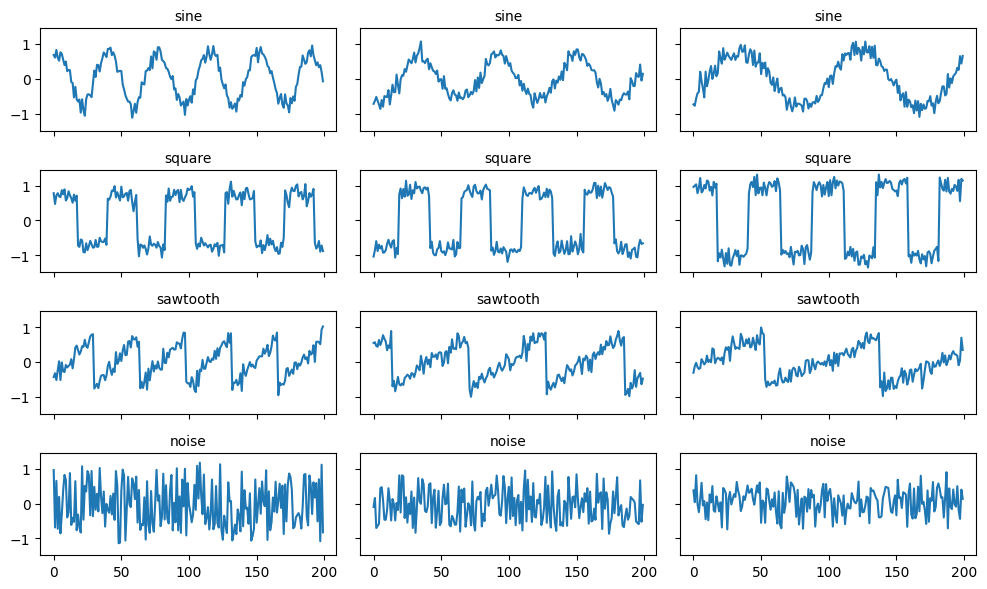

In [4]:
fig, ax = plt.subplots(len(CLASSES), 3, figsize=(10, 6), sharex=True, sharey=True)

for row, kind in enumerate(CLASSES):
	samples = x[y == kind]
	for col in range(3):
		ax[row, col].plot(samples[col, :, 0])
		ax[row, col].set_title(kind, fontsize=10)

plt.tight_layout()
plt.show()

## Préparation des données

Comme avec sklearn : labels texte → entiers avec `LabelEncoder` (ordre **alphabétique** !), puis split train/test.

Nos signaux sont déjà dans une plage raisonnable (~[-1.6, 1.6]) : pas besoin de `StandardScaler` ici.

Sur des données réelles (IMU…), pensez-y — et fittez-le **sur le train uniquement**.

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
print("Classes (ordre alphabétique) :", encoder.classes_)
NB_CLASSES = len(encoder.classes_)

x_train, x_test, y_train, y_test = train_test_split(
	x, y_enc, test_size=0.15, stratify=y_enc, random_state=42
)
print("Train :", x_train.shape, " Test :", x_test.shape)

Classes (ordre alphabétique) : ['noise' 'sawtooth' 'sine' 'square']
Train : (850, 200, 1)  Test : (150, 200, 1)


# Keras

## Construire un modèle : `Sequential`

Un modèle séquentiel est une pile de couches où l'information transite étape par étape, dans un seul sens.

<div class="alert alert-block alert-warning">
	<b>⚠️ Bonne pratique :</b> on encapsule la création dans une fonction <code>build_model()</code>.
	<p>Relancer <code>model.fit()</code> ne repart <b>pas</b> de zéro : pour ré-entraîner proprement (ou pour une cross-validation), il faut <b>recréer</b> le modèle.</p>
</div>

Premier modèle de référence : un réseau **Dense** (fully-connected).

Note : `Flatten()` vient en **premier**. Une couche `Dense` appliquée à une entrée 2D `(128, 1)` s'appliquerait indépendamment à chaque pas de temps — valide, mais ce n'est pas le réseau "classique" qu'on veut ici.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Conv1D, MaxPooling1D, GlobalAveragePooling1D

def build_dense_model():
	return Sequential(
		[
			Input((LENGTH, 1)),
			Flatten(),
			Dense(32, activation="relu"),
			Dense(16, activation="relu"),
			Dense(NB_CLASSES, activation="softmax"), # softmax : des probabilités dont la somme est 1
		]
	)

model_dense = build_dense_model()

## `model.compile()`

Configure le modèle pour l'entraînement :
- **loss** : `sparse_categorical_crossentropy` → les labels restent des entiers (0, 1, 2, 3), pas besoin de one-hot
- **optimizer** : `Adam`
- **metrics** : les statistiques à suivre pendant l'entraînement

In [7]:
model_dense.compile(
	optimizer="adam",
	loss="sparse_categorical_crossentropy",
	metrics=["accuracy"],
)
model_dense.summary() # nombre de paramètres = taille du modèle !

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,028 (27.45 KB)

 Trainable params: 7,028 (27.45 KB)

 Non-trainable params: 0 (0.00 B)

## `model.fit()`

- `validation_split=0.1` : 10 % du **train** servent de jeu de **validation** (suivi de l'apprentissage). Le **test** reste intouché jusqu'à la fin !
- `EarlyStopping` : stoppe quand la `val_loss` ne progresse plus, et `restore_best_weights=True` restaure les meilleurs poids rencontrés.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience=15, restore_best_weights=True)

history = model_dense.fit(
	x_train, y_train,
	epochs=200,
	batch_size=32,
	validation_split=0.1,
	callbacks=[es],
	verbose=False,
)
print(f"Entraînement stoppé après {len(history.history['loss'])} epochs")

Entraînement stoppé après 40 epochs


## `history` : les courbes d'apprentissage

À savoir lire : *cas idéal*, *overfitting* (val qui remonte), *underfitting* (les deux stagnent haut).

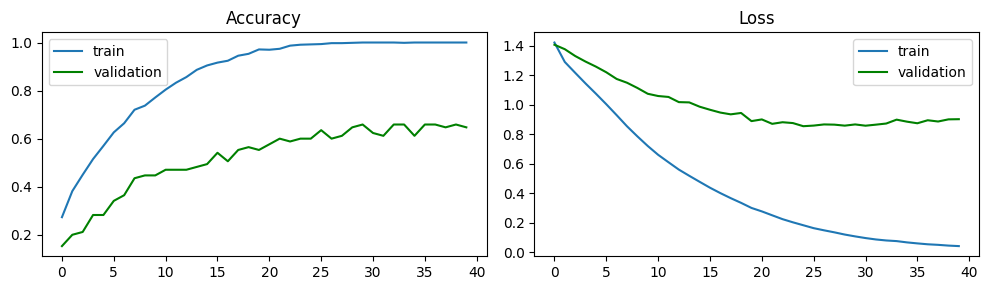

In [9]:
def plot_history(history):
	hist = history.history
	fig, ax = plt.subplots(1, 2, figsize=(10, 3))

	ax[0].plot(hist["accuracy"], label="train")
	ax[0].plot(hist["val_accuracy"], c="g", label="validation")
	ax[0].set_title("Accuracy")
	ax[0].legend()

	ax[1].plot(hist["loss"], label="train")
	ax[1].plot(hist["val_loss"], c="g", label="validation")
	ax[1].set_title("Loss")
	ax[1].legend()

	plt.tight_layout()
	plt.show()

plot_history(history)

## `model.evaluate()` et `model.predict()`

In [10]:
loss, acc_dense = model_dense.evaluate(x_test, y_test, verbose=False)
print(f"[Dense] Accuracy test : {acc_dense:.2%} / Loss : {loss:.3f}")

[Dense] Accuracy test : 58.67% / Loss : 0.954


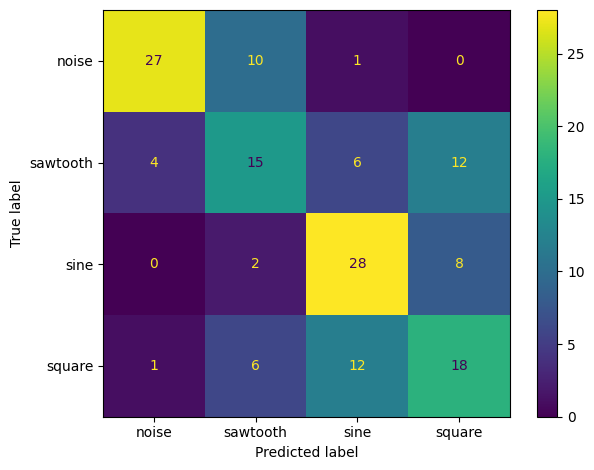

              precision    recall  f1-score   support

       noise       0.84      0.71      0.77        38
    sawtooth       0.45      0.41      0.43        37
        sine       0.60      0.74      0.66        38
      square       0.47      0.49      0.48        37

    accuracy                           0.59       150
   macro avg       0.59      0.58      0.58       150
weighted avg       0.59      0.59      0.59       150



In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

y_proba = model_dense.predict(x_test, verbose=False) # (N, 4) : probabilités par classe
y_pred = np.argmax(y_proba, axis=1)                  # la classe la plus probable

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=encoder.classes_)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# CNN : `Conv1D`

La convolution fait glisser des **kernels** (ici de taille 7) le long du signal : chaque kernel apprend à détecter un motif local (front montant, plateau, oscillation…), **où qu'il soit** dans la fenêtre.

Deux conséquences :
- plus de feature engineering : le réseau apprend lui-même ses features
- beaucoup moins de poids qu'un Dense équivalent (les kernels sont partagés sur toute la fenêtre)

In [12]:
def build_cnn_model():
	return Sequential(
		[
			Input((LENGTH, 1)),
			Conv1D(16, 7, activation="relu"),
			MaxPooling1D(2),
			Conv1D(32, 5, activation="relu"),
			GlobalAveragePooling1D(),
			Dense(NB_CLASSES, activation="softmax"),
		]
	)

model_cnn = build_cnn_model()
model_cnn.compile(
	optimizer="adam",
	loss="sparse_categorical_crossentropy",
	metrics=["accuracy"],
)
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 194, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 97, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,852 (11.14 KB)

 Trainable params: 2,852 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

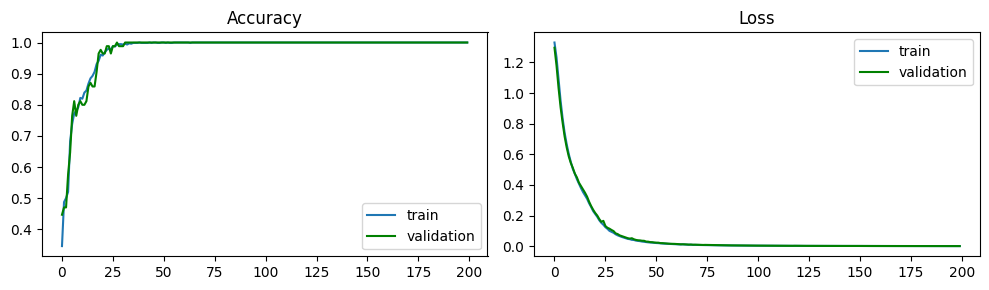

[CNN]   Accuracy test : 100.00% / Loss : 0.001
[Dense] Accuracy test : 58.67% (pour comparaison)


In [13]:
es = EarlyStopping(patience=15, restore_best_weights=True)

history = model_cnn.fit(
	x_train, y_train,
	epochs=200,
	batch_size=32,
	validation_split=0.1,
	callbacks=[es],
	verbose=False,
)
plot_history(history)

loss, acc_cnn = model_cnn.evaluate(x_test, y_test, verbose=False)
print(f"[CNN]   Accuracy test : {acc_cnn:.2%} / Loss : {loss:.3f}")
print(f"[Dense] Accuracy test : {acc_dense:.2%} (pour comparaison)")

### Bonus : à quoi ressemblent les kernels appris ?

Les poids de la première couche de convolution sont des petits "détecteurs de motifs" de 7 points, appris par rétropropagation.

Shape des kernels : (7, 1, 16)


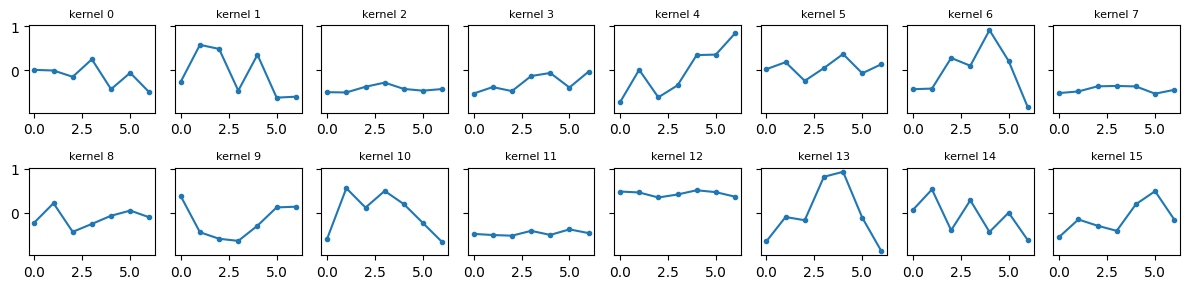

In [14]:
kernels = model_cnn.layers[0].get_weights()[0] # shape (7, 1, 16) : (kernel_size, channels_in, filters)
print("Shape des kernels :", kernels.shape)

fig, ax = plt.subplots(2, 8, figsize=(12, 3), sharey=True)
for i in range(16):
	ax[i // 8, i % 8].plot(kernels[:, :, i], marker="o", markersize=3)
	ax[i // 8, i % 8].set_title(f"kernel {i}", fontsize=8)
plt.tight_layout()
plt.show()

## Validation croisée : KFold avec Keras

<div class="alert alert-block alert-warning">
	<b>⚠️ Le piège classique :</b> contrairement à sklearn, <code>model.fit()</code> avec Keras <b>continue</b> l'entraînement existant.
	<p>Si on réutilise le même modèle à chaque fold, il a déjà "vu" les données de test des folds précédents → les scores montent artificiellement à chaque fold. Il faut <b>reconstruire le modèle dans la boucle</b>.</p>
	<p>D'où l'importance de créer le modèle dans une <b>fonction</b>.</p>
</div>

In [15]:
from sklearn.model_selection import KFold

fold = KFold(n_splits=4, shuffle=True)

for i, (train_idx, test_idx) in enumerate(fold.split(x, y_enc)):
	fold_model = build_cnn_model() # ← un modèle NEUF à chaque fold !
	fold_model.compile(
		optimizer="adam",
		loss="sparse_categorical_crossentropy",
		metrics=["accuracy"],
	)
	fold_model.fit(x[train_idx], y_enc[train_idx], epochs=60, batch_size=32, verbose=False)

	loss, accuracy = fold_model.evaluate(x[test_idx], y_enc[test_idx], verbose=False)
	print(f"Fold {i + 1} — Accuracy : {accuracy:.2%} / Loss : {loss:.3f}")

Fold 1 — Accuracy : 100.00% / Loss : 0.021
Fold 2 — Accuracy : 100.00% / Loss : 0.026
Fold 3 — Accuracy : 100.00% / Loss : 0.023
Fold 4 — Accuracy : 99.60% / Loss : 0.034


# TFLite / LiteRT

## Conversion

On convertit le modèle Keras au format `.tflite` (un flatbuffer), avec ou sans optimisation :
- **sans** : poids en float32
- **`Optimize.DEFAULT`** (dynamic range) : la majorité des poids passent en int8, les activations restent en float

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_cnn)
tflite_model = converter.convert()

converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_opt = converter.convert()

In [17]:
print(f"Taille float32       : {len(tflite_model) / 1024:.1f} KB")
print(f"Taille dynamic range : {len(tflite_model_opt) / 1024:.1f} KB")

Taille float32       : 16.1 KB
Taille dynamic range : 9.0 KB


## Tester un `.tflite` en Python : l'interpréteur LiteRT

Même API que sur le microcontrôleur, ce qui permet de valider le modèle **avant** de passer au C++ :
1. charger le modèle et allouer les tenseurs
2. récupérer les index des tenseurs d'entrée/sortie
3. boucle : `set_tensor` → `invoke` → `get_tensor`

In [18]:
from ai_edge_litert.interpreter import Interpreter

def evaluate_tflite(model_content, x_eval, y_eval, quantized_input=False):
	interpreter = Interpreter(model_content=model_content)
	interpreter.allocate_tensors()

	input_details = interpreter.get_input_details()[0]
	output_details = interpreter.get_output_details()[0]

	correct = 0
	for sample, label in zip(x_eval, y_eval):
		if quantized_input:
			scale, zero_point = input_details["quantization"]
			sample = np.round(sample / scale + zero_point) # float -> int8
			sample = np.clip(sample, -128, 127).astype(np.int8)

		interpreter.set_tensor(input_details["index"], sample.reshape(1, LENGTH, 1))
		interpreter.invoke()

		output = interpreter.get_tensor(output_details["index"])
		# Pas besoin de déquantizer pour un argmax : l'ordre des valeurs est conservé
		correct += np.argmax(output) == label

	return correct / len(y_eval)

acc_tflite = evaluate_tflite(tflite_model, x_test, y_test)
acc_tflite_opt = evaluate_tflite(tflite_model_opt, x_test, y_test)
print(f"Accuracy Keras         : {acc_cnn:.2%}")
print(f"Accuracy tflite float  : {acc_tflite:.2%}")
print(f"Accuracy dynamic range : {acc_tflite_opt:.2%}")

Accuracy Keras         : 100.00%
Accuracy tflite float  : 100.00%
Accuracy dynamic range : 100.00%


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Quantization int8 complète

Pour profiter de CMSIS-NN et des opérations SIMD sur Cortex-M, on convertit **tout** le modèle en int8 (poids **et** activations). Il faut alors :
- un **representative dataset** : quelques centaines d'échantillons pour calibrer les plages de quantization

<div class="alert alert-block alert-danger">
	<b>🚨 Attention :</b> le representative dataset doit avoir subi <b>exactement le même preprocessing</b> (scaling !) que les données d'entraînement. Calibrer sur des données non scalées alors que le modèle a appris sur des données scalées détruit l'accuracy.
</div>

In [ ]:
def representative_dataset():
	for sample in x_train[:200]: # quelques centaines d'échantillons suffisent
		yield [sample.reshape(1, LENGTH, 1).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model_cnn)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter.representative_dataset = representative_dataset

tflite_model_int8 = converter.convert()

In [20]:
print(f"Taille int8 : {len(tflite_model_int8) / 1024:.1f} KB")

Taille int8 : 9.7 KB


In [21]:
interpreter_int8 = Interpreter(model_content=tflite_model_int8)
interpreter_int8.allocate_tensors()

input_details = interpreter_int8.get_input_details()[0]
print("dtype d'entrée :", input_details["dtype"])
input_scale, input_zero_point = input_details["quantization"]
print(f"input_scale = {input_scale:.4f} / input_zero_point = {input_zero_point}")
# Côté MCU, c'est avec ces deux valeurs qu'il faudra quantizer les données capteur :
# input_int8 = round(x / input_scale) + input_zero_point

dtype d'entrée : <class 'numpy.int8'>
input_scale = 0.0121 / input_zero_point = -6


In [22]:
acc_int8 = evaluate_tflite(tflite_model_int8, x_test, y_test, quantized_input=True)

print(f"Accuracy Keras (float32) : {acc_cnn:.2%}")
print(f"Accuracy int8            : {acc_int8:.2%}")

Accuracy Keras (float32) : 100.00%
Accuracy int8            : 100.00%


## Export

Le `.tflite` est prêt à être transformé en tableau C (`xxd -i model_cnn_int8.tflite > model_data.cc`) puis embarqué avec TFLite Micro / LiteRT for Micro.

In [23]:
with open("model_cnn_int8.tflite", "wb") as f:
	f.write(tflite_model_int8)

print("Modèle sauvegardé : model_cnn_int8.tflite")

Modèle sauvegardé : model_cnn_int8.tflite
